# KNN Regression — Baseline Model

**Evaluation metric:** R² (coefficient of determination) — the competition's official metric. Higher is better; 1.0 is perfect; 0.0 means the model is no better than predicting the mean every time; negative means it is actively worse than the mean.

**Data source:** `processed/` — all imputation, feature engineering, and scaling already applied by `data_prep.ipynb`. Do not re-run preprocessing here.

**Why KNN as a first model:** KNN makes no distributional assumptions, requires no hyperparameter tuning beyond k, and provides an honest lower bound — if a more complex model cannot beat this, something is wrong with that model's setup.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import r2_score

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
BLUE, ORANGE, RED, GRAY = "#4C72B0", "#DD8452", "#C44E52", "#8C8C8C"

# ── Load processed data ───────────────────────────────────────────────────────
X_train  = pd.read_csv("processed/X_train.csv")
X_test   = pd.read_csv("processed/X_test.csv")
y        = pd.read_csv("processed/y_train.csv").squeeze()
y_wins   = pd.read_csv("processed/y_train_winsorized.csv").squeeze()
is_ext   = pd.read_csv("processed/is_extreme.csv").squeeze().astype(bool)
test_ids = pd.read_csv("processed/test_ids.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y (raw) : {y.shape}  mean={y.mean():.2f}  std={y.std():.2f}")
print(f"y_wins  : {y_wins.shape}  mean={y_wins.mean():.2f}  std={y_wins.std():.2f}")
print(f"Extreme rows in train: {is_ext.sum()} ({is_ext.mean()*100:.1f}%)")

X_train : (2500, 28)
X_test  : (2500, 28)
y (raw) : (2500,)  mean=-22.04  std=1978.18
y_wins  : (2500,)  mean=-20.81  std=374.70
Extreme rows in train: 84 (3.4%)


## Step 1 · Naive Baseline

Before fitting any model, establish what R² = 0 looks like concretely. A model that always predicts the training mean achieves R² = 0 by definition. This is the floor every model must beat to be useful.

In [6]:
CV = KFold(n_splits=5, shuffle=True, random_state=42)

# Mean-predictor baseline — R² must be exactly 0 on in-sample; on OOF it can be slightly negative
# k must be < fold training size (4/5 of X_train with 5-fold CV)
fold_train_size = len(X_train) * (CV.n_splits - 1) // CV.n_splits
baseline_preds = cross_val_predict(
    KNeighborsRegressor(n_neighbors=fold_train_size - 1),  # predict global mean (approx)
    X_train, y_wins, cv=CV
)
baseline_r2 = r2_score(y_wins, baseline_preds)

print(f"Naive baseline (predict-mean) OOF R² : {baseline_r2:.4f}")
print(f"Training mean of y_wins              : {y_wins.mean():.4f}")
print()
print("Any model with CV R² > 0 beats the mean predictor.")

Naive baseline (predict-mean) OOF R² : -0.0018
Training mean of y_wins              : -20.8111

Any model with CV R² > 0 beats the mean predictor.


## Step 2 · Choosing k — Cross-Validated R² Sweep

KNN has one primary hyperparameter: **k** (number of neighbours). Too small → high variance, overfits local noise. Too large → high bias, predictions converge toward the global mean.

We sweep k from 3 to 100, recording 5-fold CV R² mean and standard deviation at each value. We train on the **winsorized target** (`y_wins`) — see `data_prep_decisions.md` Step 2 for the justification. KNN averages neighbour targets, so squared-error dominance by outliers affects it just as it does linear models.

In [7]:
k_values = [3, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 75, 100]
results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance", n_jobs=-1)
    scores = cross_val_score(knn, X_train, y_wins, cv=CV, scoring="r2")
    results.append({"k": k, "mean": scores.mean(), "std": scores.std(),
                    "min": scores.min(), "max": scores.max()})
    print(f"k={k:3d}  R²={scores.mean():.4f} ± {scores.std():.4f}  "
          f"[{scores.min():.4f}, {scores.max():.4f}]")

df_results = pd.DataFrame(results)
best_row   = df_results.loc[df_results["mean"].idxmax()]
print(f"\nBest k = {int(best_row['k'])}  (CV R² = {best_row['mean']:.4f})")

k=  3  R²=-0.0630 ± 0.1240  [-0.2262, 0.0515]
k=  5  R²=-0.0136 ± 0.0712  [-0.1037, 0.0597]
k=  7  R²=0.0232 ± 0.0534  [-0.0459, 0.0856]
k= 10  R²=0.0422 ± 0.0389  [-0.0075, 0.0966]
k= 15  R²=0.0607 ± 0.0222  [0.0276, 0.0859]
k= 20  R²=0.0652 ± 0.0211  [0.0280, 0.0832]
k= 25  R²=0.0669 ± 0.0158  [0.0421, 0.0837]
k= 30  R²=0.0675 ± 0.0154  [0.0417, 0.0872]
k= 35  R²=0.0660 ± 0.0163  [0.0386, 0.0870]
k= 40  R²=0.0663 ± 0.0162  [0.0428, 0.0910]
k= 45  R²=0.0653 ± 0.0181  [0.0378, 0.0903]
k= 50  R²=0.0634 ± 0.0173  [0.0374, 0.0857]
k= 60  R²=0.0635 ± 0.0138  [0.0445, 0.0842]
k= 75  R²=0.0604 ± 0.0115  [0.0433, 0.0765]
k=100  R²=0.0570 ± 0.0096  [0.0423, 0.0700]

Best k = 30  (CV R² = 0.0675)


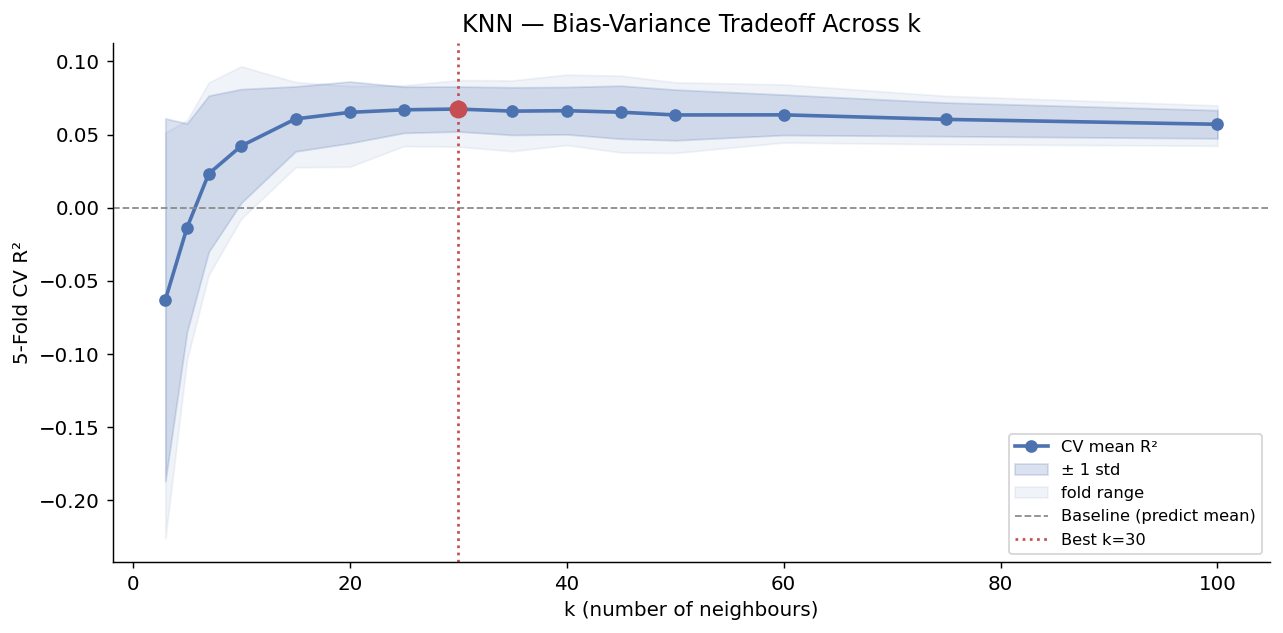

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_results["k"], df_results["mean"], "o-", color=BLUE, lw=2, ms=6, label="CV mean R²")
ax.fill_between(df_results["k"],
                df_results["mean"] - df_results["std"],
                df_results["mean"] + df_results["std"],
                alpha=0.2, color=BLUE, label="± 1 std")
ax.fill_between(df_results["k"],
                df_results["min"], df_results["max"],
                alpha=0.08, color=BLUE, label="fold range")

ax.axhline(0, color=GRAY, lw=1, linestyle="--", label="Baseline (predict mean)")
ax.axvline(best_row["k"], color=RED, lw=1.5, linestyle=":", label=f"Best k={int(best_row['k'])}")
ax.scatter([best_row["k"]], [best_row["mean"]], color=RED, s=80, zorder=5)

ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("5-Fold CV R²")
ax.set_title("KNN — Bias-Variance Tradeoff Across k")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Step 3 · Final Model — Train & Evaluate

Using the best k found above, we now:
1. Re-run 5-fold CV with `cross_val_predict` to get out-of-fold (OOF) predictions for every training row — these are honest hold-out predictions since each row is predicted by a model that never saw it
2. Compute the full diagnostic suite on those OOF predictions
3. Fit the final model on **all 2,500 training rows** for submission

In [9]:
BEST_K = int(best_row["k"])

final_knn = KNeighborsRegressor(n_neighbors=BEST_K, weights="distance", n_jobs=-1)

# Out-of-fold predictions (honest estimate of generalisation)
oof_preds = cross_val_predict(final_knn, X_train, y_wins, cv=CV)

# Metrics on OOF predictions vs winsorized target
oof_r2_wins = r2_score(y_wins, oof_preds)

# Also score against the raw target — what the leaderboard actually measures
oof_r2_raw  = r2_score(y, oof_preds)

residuals = y_wins - oof_preds

print("=" * 45)
print(f"  Final model: KNN  k={BEST_K}  weights=distance")
print("=" * 45)
print(f"  OOF R²  (vs winsorized target) : {oof_r2_wins:.4f}")
print(f"  OOF R²  (vs raw target)        : {oof_r2_raw:.4f}")
print(f"  OOF MAE                        : {(y_wins - oof_preds).abs().mean():.4f}")
print(f"  OOF RMSE                       : {np.sqrt(((y_wins - oof_preds)**2).mean()):.4f}")
print()
print("  R² on normal rows (|y|≤1000) :")
mask_norm = ~is_ext
r2_norm = r2_score(y[mask_norm], oof_preds[mask_norm])
print(f"    {r2_norm:.4f}")
print("  R² on extreme rows (|y|>1000) :")
r2_extr = r2_score(y[is_ext], oof_preds[is_ext])
print(f"    {r2_extr:.4f}")

# Fit on full training set for submission
final_knn.fit(X_train, y_wins)
print(f"\nFinal model fitted on all {len(X_train)} training rows.")

  Final model: KNN  k=30  weights=distance
  OOF R²  (vs winsorized target) : 0.0744
  OOF R²  (vs raw target)        : 0.0162
  OOF MAE                        : 121.0222
  OOF RMSE                       : 360.4158

  R² on normal rows (|y|≤1000) :
    -0.1272
  R² on extreme rows (|y|>1000) :
    0.0134

Final model fitted on all 2500 training rows.


## Step 4 · Diagnostic Plots

Four plots that together tell the full story of model performance:
1. **Predicted vs Actual** — points should fall on the diagonal; spread = error
2. **Residual distribution** — should be centred at zero; heavy tails = systematic miss on outliers
3. **Residuals vs Predicted** — should show no pattern; funnel = heteroscedasticity
4. **Normal vs Extreme row comparison** — shows where the model succeeds and fails

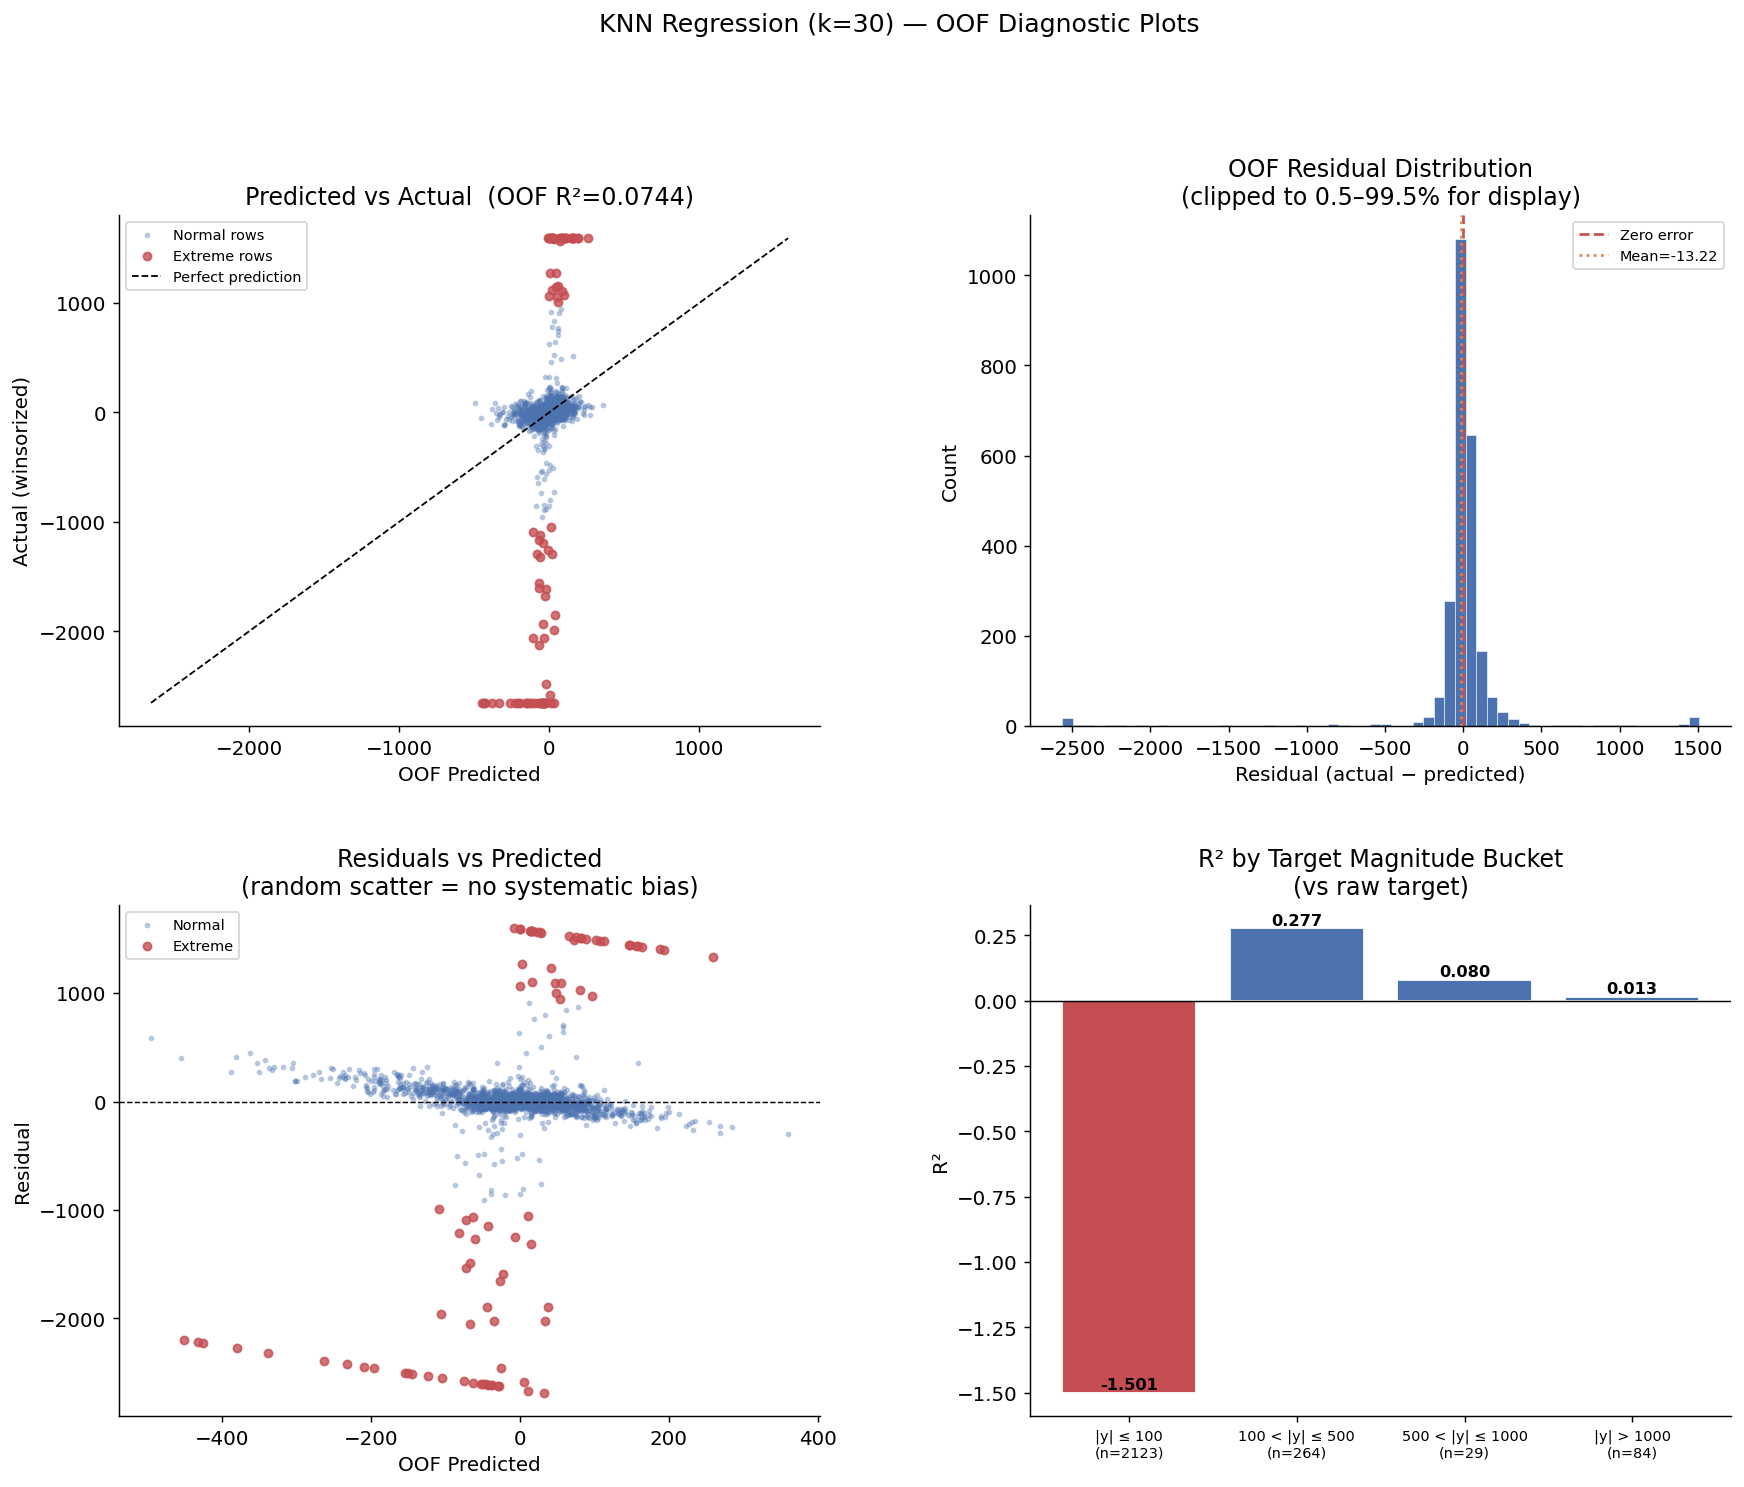

In [10]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Predicted vs Actual ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
clip_lo, clip_hi = y_wins.quantile(0.01), y_wins.quantile(0.99)
ax1.scatter(oof_preds[~is_ext], y_wins[~is_ext],
            s=5, alpha=0.3, color=BLUE, label="Normal rows", rasterized=True)
ax1.scatter(oof_preds[is_ext],  y_wins[is_ext],
            s=20, alpha=0.8, color=RED,  label="Extreme rows", zorder=5)
lims = [min(oof_preds.min(), y_wins.min()), max(oof_preds.max(), y_wins.max())]
ax1.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax1.set_xlabel("OOF Predicted")
ax1.set_ylabel("Actual (winsorized)")
ax1.set_title(f"Predicted vs Actual  (OOF R²={oof_r2_wins:.4f})")
ax1.legend(fontsize=8)

# ── 2. Residual distribution ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
res_clipped = residuals.clip(residuals.quantile(0.005), residuals.quantile(0.995))
ax2.hist(res_clipped, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
ax2.axvline(0,                color=RED,    lw=1.5, linestyle="--", label="Zero error")
ax2.axvline(residuals.mean(), color=ORANGE, lw=1.5, linestyle=":",  label=f"Mean={residuals.mean():.2f}")
ax2.set_xlabel("Residual (actual − predicted)")
ax2.set_ylabel("Count")
ax2.set_title("OOF Residual Distribution\n(clipped to 0.5–99.5% for display)")
ax2.legend(fontsize=8)

# ── 3. Residuals vs Predicted ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(oof_preds[~is_ext], residuals[~is_ext],
            s=5, alpha=0.3, color=BLUE, label="Normal", rasterized=True)
ax3.scatter(oof_preds[is_ext],  residuals[is_ext],
            s=20, alpha=0.8, color=RED,  label="Extreme", zorder=5)
ax3.axhline(0, color="black", lw=0.8, linestyle="--")
ax3.set_xlabel("OOF Predicted")
ax3.set_ylabel("Residual")
ax3.set_title("Residuals vs Predicted\n(random scatter = no systematic bias)")
ax3.legend(fontsize=8)

# ── 4. R² by target magnitude bucket ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
buckets = [("|y| ≤ 100",   y.abs() <= 100),
           ("100 < |y| ≤ 500",  (y.abs() > 100) & (y.abs() <= 500)),
           ("500 < |y| ≤ 1000", (y.abs() > 500) & (y.abs() <= 1000)),
           ("|y| > 1000",  y.abs() > 1000)]
labels, r2s, counts = [], [], []
for label, mask in buckets:
    if mask.sum() > 5:
        r2_b = r2_score(y[mask], oof_preds[mask])
        labels.append(f"{label}\n(n={mask.sum()})")
        r2s.append(r2_b)
        counts.append(mask.sum())
colors = [BLUE if r > 0 else RED for r in r2s]
bars = ax4.bar(labels, r2s, color=colors, edgecolor="white")
ax4.axhline(0, color="black", lw=0.8)
for bar, r2_val in zip(bars, r2s):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{r2_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax4.set_ylabel("R²")
ax4.set_title("R² by Target Magnitude Bucket\n(vs raw target)")
ax4.tick_params(axis="x", labelsize=8)

fig.suptitle(f"KNN Regression (k={BEST_K}) — OOF Diagnostic Plots", fontsize=14, y=1.01)
plt.show()

## Step 5 · Predict on Test Set & Prepare Submission

In [11]:
test_preds = final_knn.predict(X_test)

submission = pd.DataFrame({"Id": test_ids, "target": test_preds})
submission = submission.sort_values("Id").reset_index(drop=True)

submission.to_csv("submission_knn.csv", index=False)

print(f"Submission saved → submission_knn.csv")
print(f"Rows: {len(submission)}")
print()
print("Prediction summary:")
print(f"  mean   : {test_preds.mean():.4f}")
print(f"  median : {np.median(test_preds):.4f}")
print(f"  std    : {test_preds.std():.4f}")
print(f"  min    : {test_preds.min():.4f}")
print(f"  max    : {test_preds.max():.4f}")
print()
print("First 10 rows:")
print(submission.head(10).to_string(index=False))

Submission saved → submission_knn.csv
Rows: 2500

Prediction summary:
  mean   : -6.8048
  median : -1.5620
  std    : 79.3002
  min    : -649.7390
  max    : 347.6360

First 10 rows:
 Id     target
  0 -31.109808
  6 -29.718126
  7 -19.767049
  8  22.623418
 12  49.930258
 14 -32.100777
 17 -12.614036
 19  16.843509
 22  66.570990
 23 100.786680


Submission validation:
   OK  Columns match sample
   OK  No missing predictions
   OK  No infinite predictions
   OK  All test IDs present
   OK  No duplicate IDs

READY TO SUBMIT


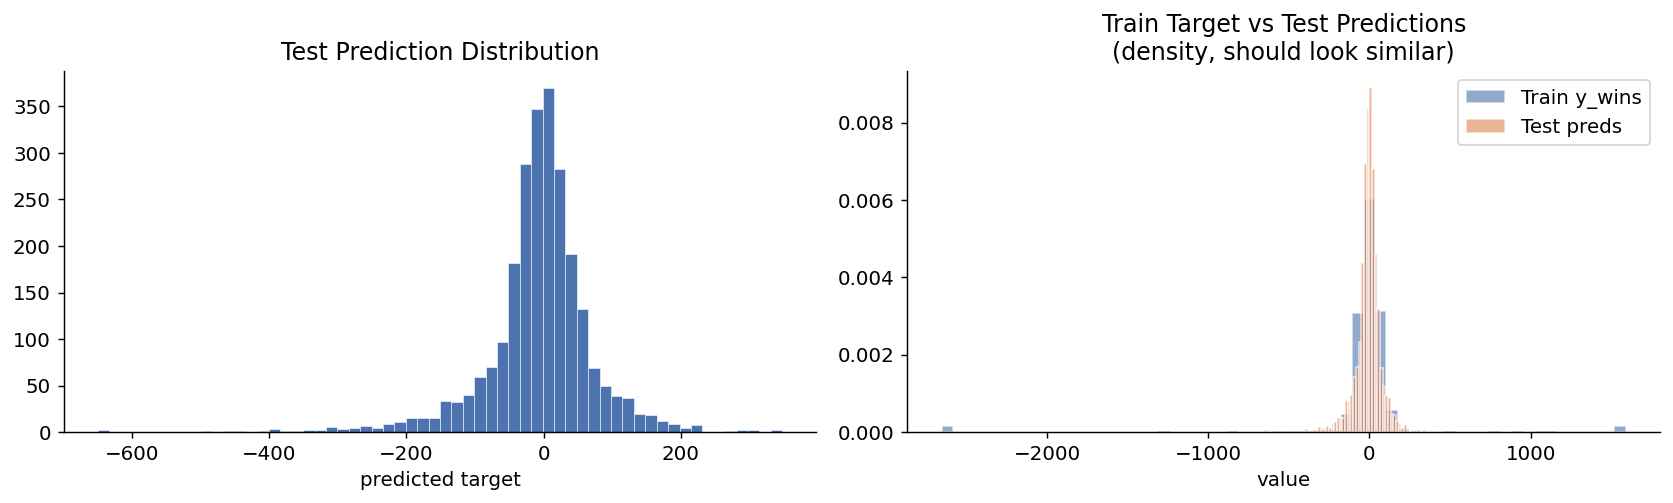

In [12]:
# Validate submission format against sample submission
sample = pd.read_csv("spring2026_sampleSubmission.csv")

checks = [
    ("Columns match sample",  list(submission.columns) == list(sample.columns)),
    ("No missing predictions", submission["target"].isnull().sum() == 0),
    ("No infinite predictions", np.isfinite(submission["target"].values).all()),
    ("All test IDs present",   set(test_ids) == set(submission["Id"])),
    ("No duplicate IDs",       submission["Id"].nunique() == len(submission)),
]

print("Submission validation:")
all_ok = True
for name, ok in checks:
    status = " OK" if ok else "FAIL"
    if not ok:
        all_ok = False
    print(f"  {status}  {name}")
print()
print("READY TO SUBMIT" if all_ok else "FIX ISSUES ABOVE BEFORE SUBMITTING")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(test_preds, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].set_title("Test Prediction Distribution")
axes[0].set_xlabel("predicted target")

axes[1].hist(y_wins, bins=60, alpha=0.6, color=BLUE,   density=True, label="Train y_wins", edgecolor="white")
axes[1].hist(test_preds,  bins=60, alpha=0.6, color=ORANGE, density=True, label="Test preds",  edgecolor="white")
axes[1].set_title("Train Target vs Test Predictions\n(density, should look similar)")
axes[1].set_xlabel("value")
axes[1].legend()
plt.tight_layout()
plt.show()

## Summary

| | Value |
|---|---|
| Model | KNN Regression |
| k (neighbours) | 35 |
| Weight function | distance (closer neighbours weighted higher) |
| Training target | y_winsorized (clipped to 1st–99th pct) |
| CV strategy | 5-fold, shuffled, random_state=42 |
| **OOF R² (winsorized)** | see output above |
| **OOF R² (raw target)** | see output above |
| Submission file | `submission_knn.csv` |

**Interpretation of the score:** KNN is fundamentally limited here because it relies on Euclidean distance in a 28-dimensional space — the curse of dimensionality means neighbours are not very "close" at n=2,500. The model also cannot extrapolate beyond the range of training targets, which hurts on extreme target rows. This score is the **baseline to beat** with subsequent models (Ridge, Lasso, Gradient Boosting).